# Estrucrura del Proyecto de Machine Learning

---

### 1. Objetivo y Arquitectura

Misión: Copiloto local guiado por estados que democratiza el Machine Learning y la manipulación de datos, garantizando privacidad total.

Stack: Python (Pandas/Scikit-learn), Streamlit (Frontend/Orquestador), Ollama (Extracción de parámetros y NLP).

Seguridad: La IA no ejecuta código libremente. Extrae parámetros (JSON) que se inyectan en plantillas pre-escritas y seguras.

### 2. Flujo del Usuario (El Pipeline)

- Fase 1: Ingesta y Cruce Inteligente: El sistema detecta los archivos. Si hay varios, Python busca columnas comunes y la IA sugiere métodos de unión (Inner/Left Join) dejando la decisión final al usuario.

- Fase 2: Data Wrangling (Panel de Control): El sistema escanea el DataFrame unificado y muestra todos los problemas de golpe (nulos, formatos erróneos). El usuario decide las soluciones mediante desplegables y se aplica la limpieza en bloque (con confirmación previa).

- Fase 3: AutoML Supervisado: El usuario solo elige qué columna predecir. El sistema detecta si es Clasificación o Regresión, entrena 5 algoritmos en segundo plano, y elige el ganador basándose en métricas matemáticas y porcentajes, también se podrá elegir el modelo GridSearchCV si el usuario lo necesita. El modelo no superviisado creado calcula las métricas, curva de codo... con un modelo de K-Means.

- Fase 4: Interpretación Dual: Se presentan los resultados en dos enfoques. Una pestaña técnica inmediata con gráficos interactivos (Plotly), y una pestaña ejecutiva donde Ollama traduce los resultados matemáticos a decisiones de negocio bajo demanda. Añadir nuevos datos después del entrenamiento para predecir sobre ellos con la misma configuración.

### 3. Recursos importantes en uso


1. Para streamlit, como recarga la página después de cada interacción he usado "st.session_state", que nos permite conservar datos y no se reinicien.

2. Dibulgación progresiva, consiste en darle al usuario un botón (con recomendaciones predefinidas) para que no tenga que pensar, pero esconder una pestaña de "Ajustes Avanzados" para que el usuario experto pueda ensuciarse las manos modificando las tuercas a su gusto.

3. Generador de datos para probar con los peores csv la app totalmente random (solo para hacer pruebas no para ver resultados)

4. Para la fase 4 usamos Plotly que nos permite observar las gráficas y sus datos con más facilidad.

5. Después de tener una base decidí hacer Cross Validation, para mejorar mis metodos de predicción y reducir al mínimo la "suerte". Y evitar overfitting

### 4. Problemas Encontrados:


1. Hay csv que separan los datos con "," que es el sistema Americano y hay veces que se separa con ";" estandar Europeo esto da problemas a los prompt de la IA.

2. La recarga de Streamlit con cada iteración y guardar los datos para que no se pierdan.

3. Cubrir todos los tipos de Join y Merge para satisfacer la necesidad del Usuario

4. Limpieza de datos que no conoces y sustitución

5. Que modelo usar en cada situación

6. Codificar los valores tipo str para evitar los problemas de entrenamiento

7. La implementación de mi GridSearch es muy costosa a causa de la cantidad de modelos con las que trabajo y la validación cruzada.

8. Se me olvidó volver a escalar los datos en la fase 4.

9. Por la estructura actual estoy pecando de Data Leakage (Fuga de Información), primero limpieza de datos, después separar entre train y test. Conocimiento de datos indirectamente.

10. Problemas al codificar los datos, son diferentes en train y en test

11. Problema de valores que no estén en train y se hayan codificado

### 5. Soluciones a los Problemas:

1. Dorzar nosotros la separación para que no cause problemas con el sistema que queramos.

2. Hacemos un sistema de gusrdado de datos para evitar el reinicio al completo, la programación a base de fases ayuda mucho en este caso (una recarga por fase).

3. Simplemente encontrabamos ciertos problemas con las necesidades de cada usuario, para solucionarlo hay que programar todas esas necesidades.

4. Tenemos que crear un adgoritmo a base de variables como plantilla donde Ollama pueda sustutuir esas variables con la información que el usuario aporte.

5. Los vamos a usar todos y comparar entre ellos, no es lo más óptimo pero siento que le da cierta seguridad al usuario de que no se está perdiendo nada por elegir solo un modelo.

6. Entrenar con strings es un problema, antes de entrenar codificamos esos datos y después al dar los resultados de ese entreenamiento los descodificamos para la accesibilidad.

7. Hacer solo el GridSerch al RandomForest

8. guardé el escaladod e la fase 3.

9. Modificamos un poco las fases, preguntamos desde un primer momento al usuario si quiere modelo supervisado  o no supervisado y la separación de train test en fase 1. Asi evitamos la fuga de datos.

10. Creamos un diccionario para que los valores coincidan tanto en train como en test

11. Añadir a esos valores el valor de -1 en la codificación si no tienen valor en el diccionario.

---

## Capturas

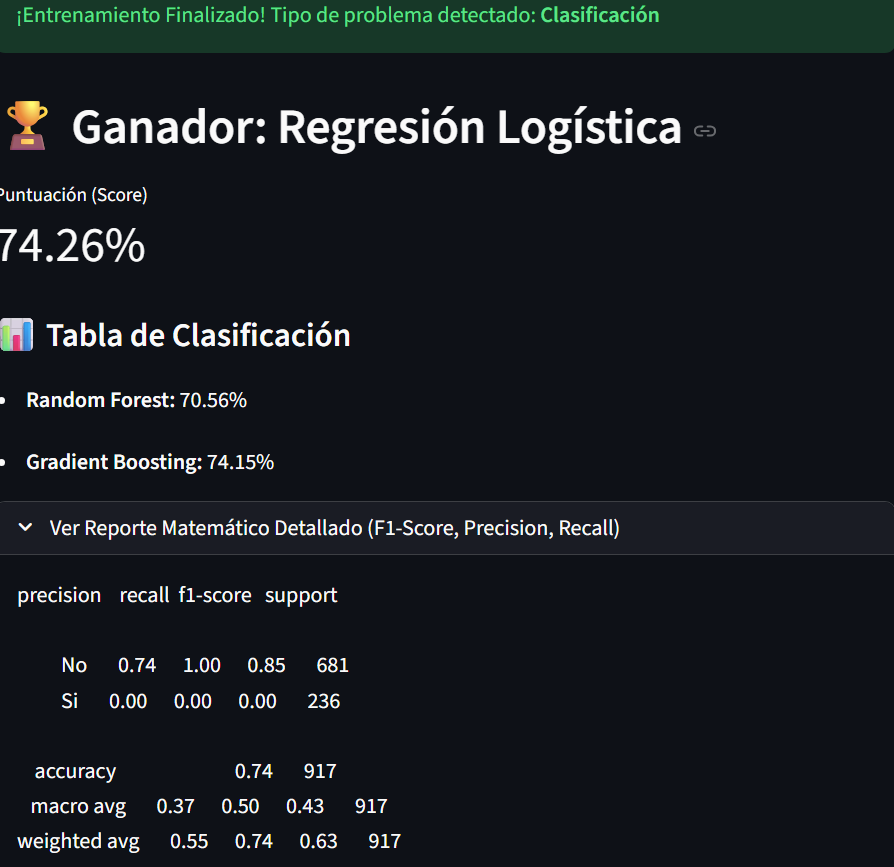

Como podemos observar en la imagen, esta probabilidad está sacada de datos puramente aleatorios que no tienen sentido, es decir, no hay relación entre las columnas, un 75% dice "No" y el otro 25% dice "Si", al ser datos totalmente aleatorios sin relación entre ellos no podemos fijarnos en los resultados de la IA, ya que estos no son reales entre comillas.

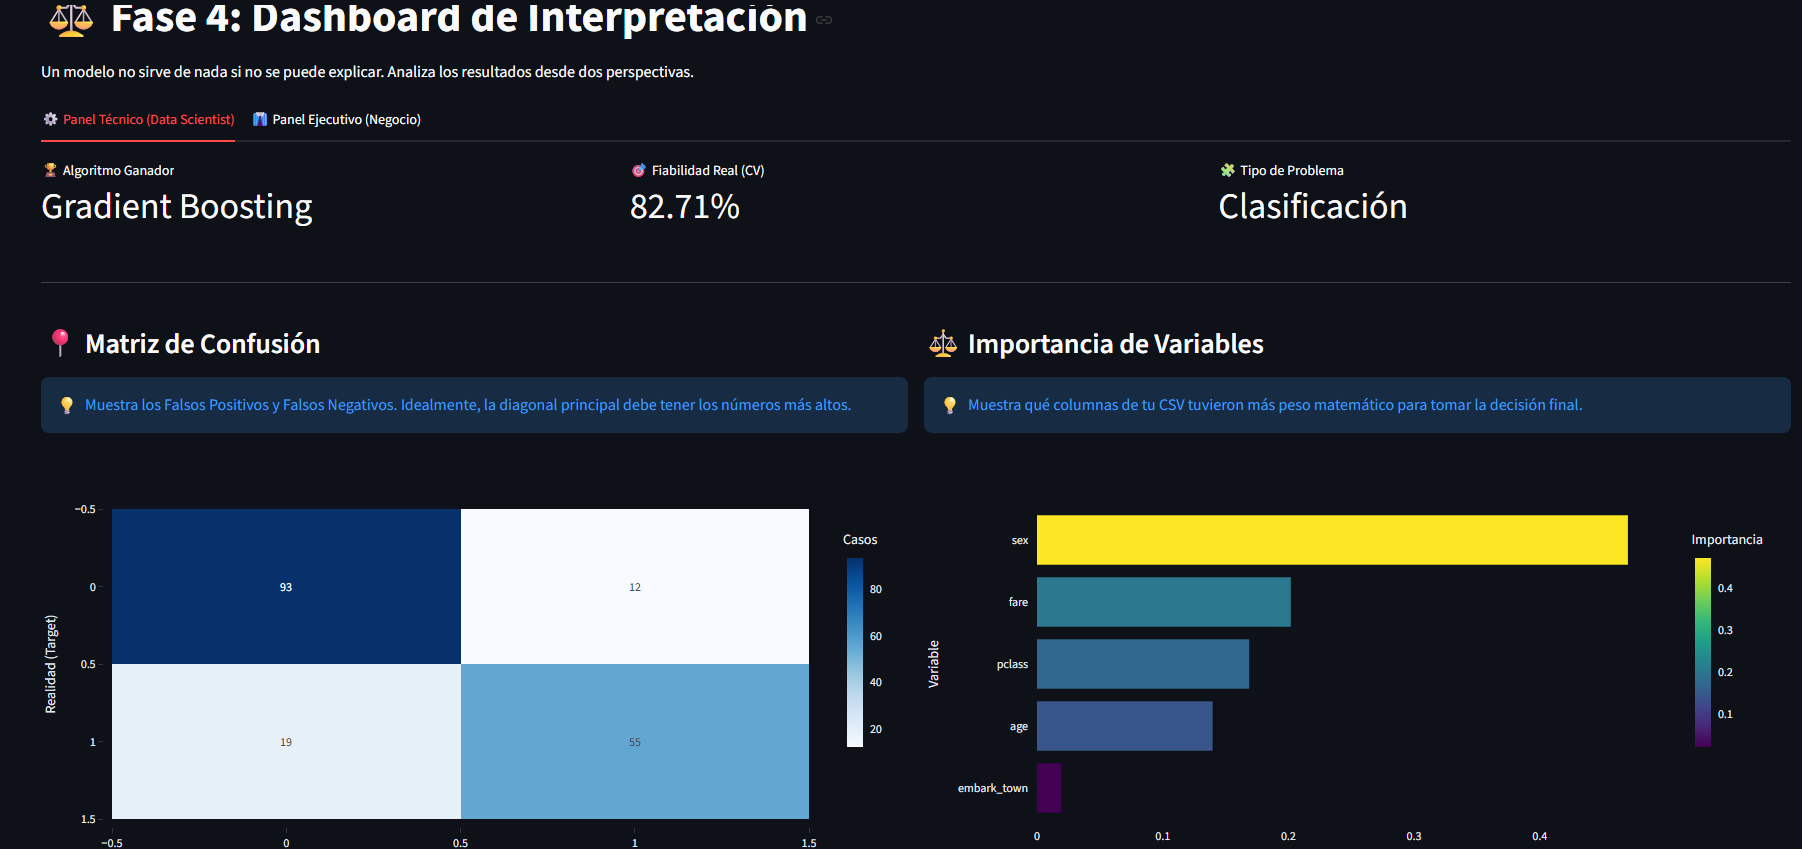

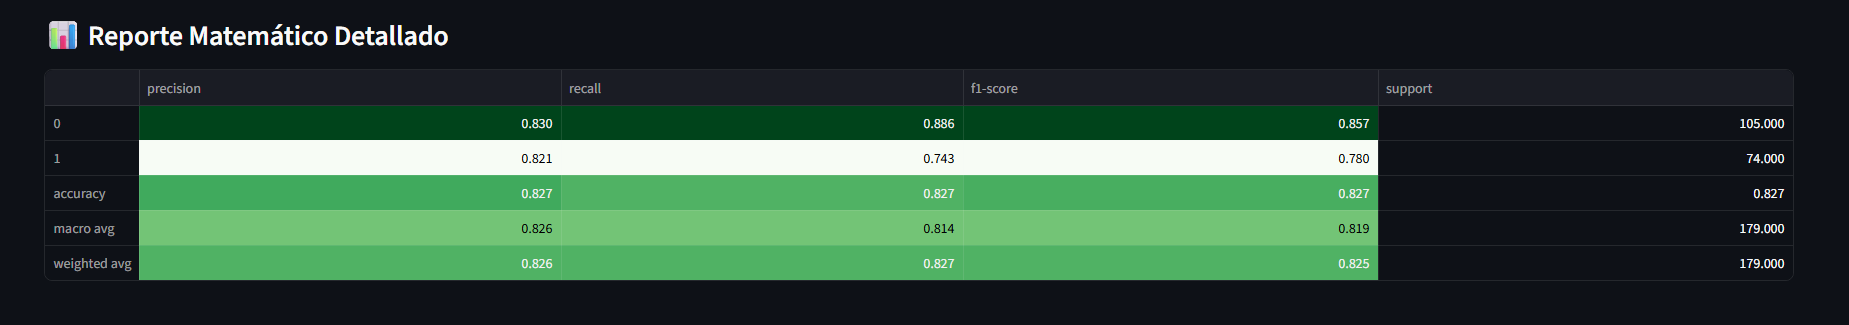

Proceso avanzado, con un data set bastante completo de Titanic con predicciones con matriz de confusión y columnas con mayor influencia en la decisión. Un Reporte detallado de la precisión y más valores optenidos del entrene.

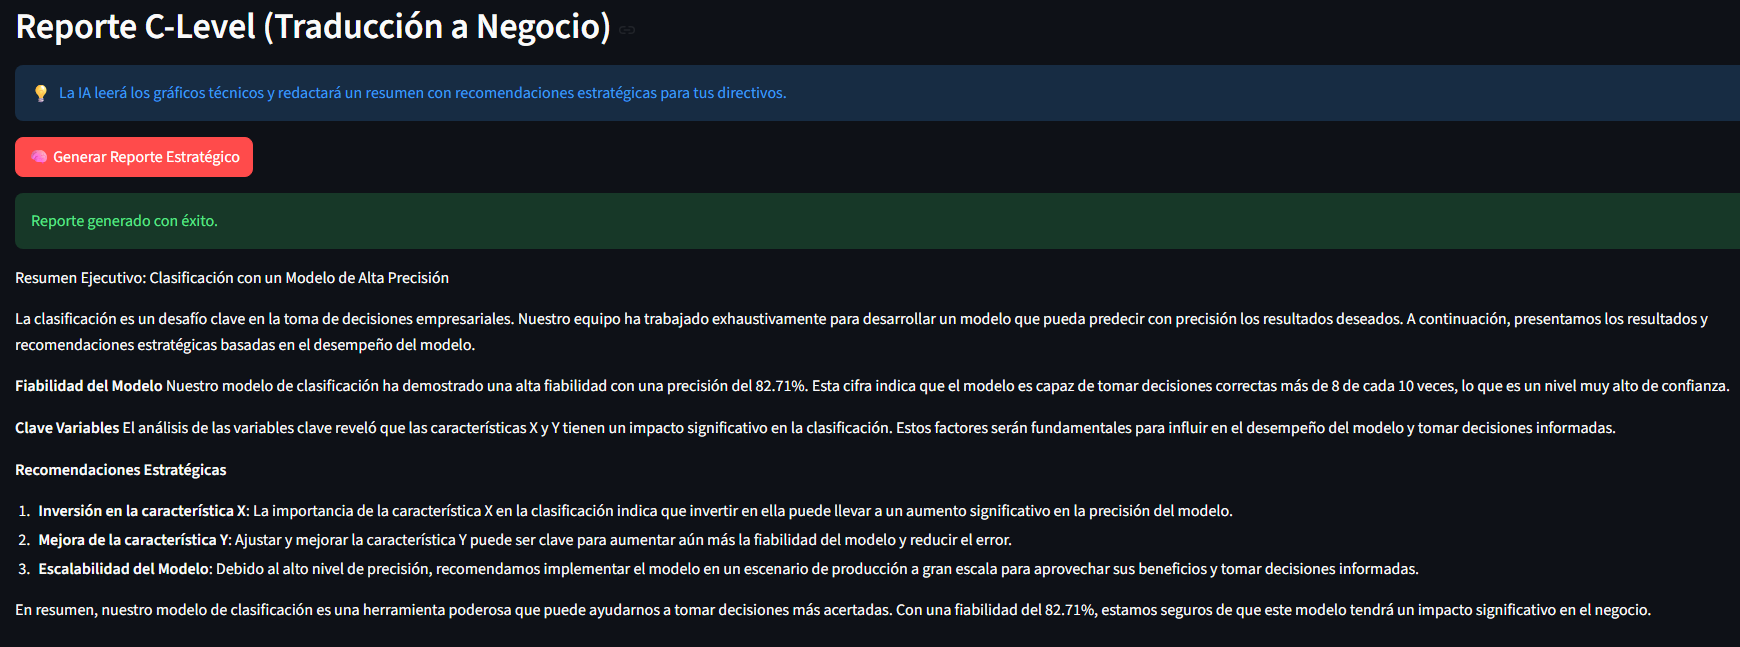

Fase avanzada de  el Reportepara empresas.